# 04 两比特耦合与串扰建模（4 月）

目标：建立两比特耦合 + 串扰模型，观察门保真度与泄露趋势。


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'examples' / 'backend.yaml').exists():
            return p
    raise FileNotFoundError('???????????? pyproject.toml ? examples/backend.yaml?')

ROOT = find_project_root(Path.cwd())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from qsim.ui.notebook import run_workflow

BACKEND_PATH = ROOT / 'examples' / 'backend.yaml'
OUT_ROOT = ROOT / 'examples' / 'noise_simulation_tests' / 'runs' / 'roadmap_2026H1'
OUT_ROOT.mkdir(parents=True, exist_ok=True)
print('ROOT =', ROOT)
print('BACKEND_PATH =', BACKEND_PATH)
print('OUT_ROOT =', OUT_ROOT)


def run_case(tag: str, qasm_text: str, hardware: dict | None = None, noise: dict | None = None, engine: str = 'qutip'):
    out_dir = OUT_ROOT / tag
    return run_workflow(
        qasm_text=qasm_text,
        backend_path=str(BACKEND_PATH),
        out_dir=str(out_dir),
        hardware=hardware or {},
        noise=noise or {},
        engine=engine,
        persist_artifacts=True,
        export_dxf=False,
    )


def get_metric(result: dict, key: str, default: float = np.nan) -> float:
    obs = result.get('analysis', {}).get('observables', {}).get('values', {})
    return float(obs.get(key, default))

ROOT = D:\超导量子计算机噪声抑制\qsim
BACKEND_PATH = D:\超导量子计算机噪声抑制\qsim\examples\backend.yaml
OUT_ROOT = D:\超导量子计算机噪声抑制\qsim\runs\roadmap_2026H1


In [2]:
QASM_2Q = """
OPENQASM 3;
qubit[2] q;
bit[2] c;
h q[0];
cx q[0], q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];
"""

c:\Users\yijia\anaconda3\Lib\site-packages\scipy\integrate\_ode.py:1011: UserWarning: _zvode: Excess work done on this call. (Perhaps wrong MF.)
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,


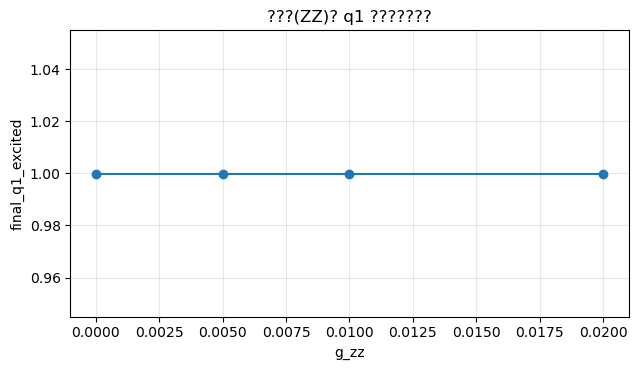

In [3]:
gzz_list = [0.0, 0.005, 0.01, 0.02]
metric_q1 = []
for gzz in gzz_list:
    hw = {'qubit_freqs_hz': [5.0e9, 5.1e9], 'couplings': [{'i':0,'j':1,'g':0.02,'kind':'xx+yy'},{'i':0,'j':1,'g':gzz,'kind':'zz'}]}
    r = run_case(f'04_gzz_{gzz:.3f}', QASM_2Q, hardware=hw, noise={'model':'markovian_lindblad','t1':120.0,'t2':90.0})
    metric_q1.append(get_metric(r, 'final_q1_excited'))

plt.figure(figsize=(6.5, 3.8))
plt.plot(gzz_list, metric_q1, marker='o')
plt.title('???(ZZ)? q1 ???????')
plt.xlabel('g_zz'); plt.ylabel('final_q1_excited'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()